In [1]:
# ============================================
# CELL: Imports
# Purpose:
# Import required libraries for generalization experiments
# ============================================

import pandas as pd

import numpy as np

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report

)

In [2]:
# ============================================
# CELL: Load Dataset
# Purpose:
# Load extracted PE features dataset
# ============================================

df = pd.read_csv("../data/pe_features(New).csv")

print(df.shape)

df.head()

(1649, 18)


,sha256,file_name,family,file_size,num_sections,many_sections,size_of_image,size_of_code,entry_point,num_imports,num_dlls,avg_entropy,max_entropy,min_entropy,has_crypto,has_bcrypt,has_file_ops,label
0,fac81bcdcb6ccf8505dfa44a9b4756a50e67b89f8c8fcf...,3uTools.exe,benign,13675880,6,0,13672448,9740288,8547568,4313,51,5.135459,6.374358,2.818603,0,0,1,0
1,8fdeb6c13162c9398e97b66c4f0a780c1e270e300a637e...,3uViewer.exe,benign,989928,6,0,978944,54784,51084,693,22,4.562831,6.085465,3.433966,0,0,0,0
2,7faad7057f2f88a431803c32fb7d272199bba89de3dc60...,7z.exe,benign,492608,6,0,491520,318976,319776,127,5,4.300758,6.285946,1.232928,0,0,1,0
3,0a038cc8dc46b6d50245c6951dc238fba63654a0cb3d23...,CrashReport.exe,benign,971992,5,0,970752,561664,383673,279,12,5.502765,6.607745,4.518242,0,0,0,0
4,b58aeb18d26cfd9b63c9ccfa0ebfe40d9ab7a01b4c9856...,InfInstallerx64.exe,benign,217152,6,0,221184,135680,56616,107,5,4.909627,6.413611,3.484201,0,0,0,0


In [3]:
# ============================================
# CELL: Dataset Inspection
# Purpose:
# Inspect family distribution
# ============================================

print(df["family"].value_counts())

family
benign         936
raworld         80
trigona         80
wannacry        80
akira           80
lockbit         80
blackmatter     80
medusa          75
qilin           59
cactus          50
blackcat        49
Name: count, dtype: int64


In [4]:
# ============================================
# CELL: Define Held-Out Family
# Purpose:
# Select unseen ransomware family for testing
# ============================================

UNSEEN_FAMILY = "medusa"

In [5]:
# ============================================
# CELL: Prepare Features
# Purpose:
# Separate features and labels
# ============================================

DROP_COLUMNS = [

    "label",
    "family",
    "sha256",
    "file_name"

]

X = df.drop(columns=DROP_COLUMNS)

y = df["label"]

In [6]:
# ============================================
# CELL: Family-Aware Split
# Purpose:
# Train on all families except the held-out family
# ============================================

train_mask = df["family"] != UNSEEN_FAMILY

test_mask = df["family"] == UNSEEN_FAMILY

X_train = X[train_mask]

y_train = y[train_mask]

X_test = X[test_mask]

y_test = y[test_mask]

print("[INFO] Train samples:", len(X_train))

print("[INFO] Test ransomware samples:", len(X_test))

[INFO] Train samples: 1574
[INFO] Test ransomware samples: 75


In [7]:
# ============================================
# CELL: Add Benign Samples
# Purpose:
# Add benign files to held-out family test set
# ============================================

benign_mask = df["family"] == "benign"

X_benign = X[benign_mask].sample(

    100,

    random_state=42

)

y_benign = y[benign_mask].sample(

    100,

    random_state=42

)

X_test = pd.concat([

    X_test,
    X_benign

])

y_test = pd.concat([

    y_test,
    y_benign

])

print("[INFO] Final test samples:", len(X_test))

[INFO] Final test samples: 175


In [8]:
# ============================================
# CELL: Train Model
# Purpose:
# Train RandomForest on known ransomware families
# ============================================

model = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

model.fit(

    X_train,

    y_train

)

print("[SUCCESS] Model trained")

[SUCCESS] Model trained


In [9]:
# ============================================
# CELL: Evaluate Model
# Purpose:
# Evaluate performance on unseen ransomware family
# ============================================

pred = model.predict(X_test)

print(classification_report(

    y_test,

    pred

))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80       100
           1       1.00      0.35      0.51        75

    accuracy                           0.72       175
   macro avg       0.84      0.67      0.66       175
weighted avg       0.81      0.72      0.68       175



In [10]:
# ============================================
# CELL: Metrics
# Purpose:
# Compute evaluation metrics
# ============================================

acc = accuracy_score(y_test, pred)

precision = precision_score(y_test, pred)

recall = recall_score(y_test, pred)

f1 = f1_score(y_test, pred)

print(f"Accuracy : {acc:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

Accuracy : 0.7200
Precision: 1.0000
Recall   : 0.3467
F1 Score : 0.5149


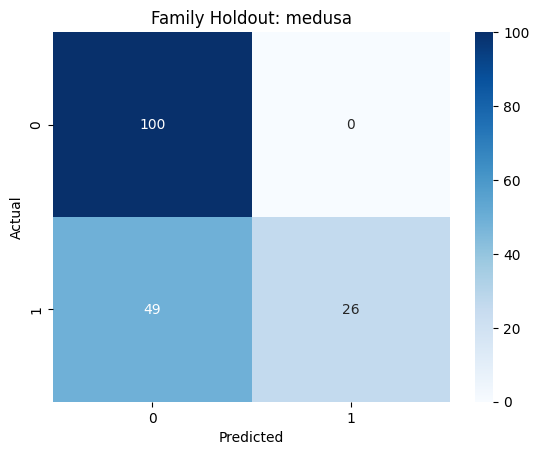

In [11]:
# ============================================
# CELL: Confusion Matrix
# Purpose:
# Visualize prediction performance
# ============================================

from sklearn.metrics import confusion_matrix

import seaborn as sns

import matplotlib.pyplot as plt

cm = confusion_matrix(

    y_test,

    pred

)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(

    f"Family Holdout: {UNSEEN_FAMILY}"

)

plt.show()

In [12]:
# ============================================
# CELL: False Negative Analysis
# Purpose:
# Analyze ransomware samples missed by the model
# ============================================

fn_mask = (

    (y_test == 1)

    &

    (pred == 0)

)

fn_samples = X_test[fn_mask]

print("=" * 60)

print("False Negative Samples")

print("=" * 60)

print(

    f"[INFO] False Negatives: {len(fn_samples)}"

)

print("\nFalse Negative Mean Features:\n")

print(

    fn_samples.mean()

)

# ============================================
# Compare with True Positives
# ============================================

tp_mask = (

    (y_test == 1)

    &

    (pred == 1)

)

tp_samples = X_test[tp_mask]

print("\n" + "=" * 60)

print("True Positive Samples")

print("=" * 60)

print(

    f"[INFO] True Positives: {len(tp_samples)}"

)

print("\nTrue Positive Mean Features:\n")

print(

    tp_samples.mean()

)

False Negative Samples
[INFO] False Negatives: 49

False Negative Mean Features:

file_size        659112.000000
num_sections          5.163265
many_sections         0.102041
size_of_image    697741.061224
size_of_code     450445.061224
entry_point      255221.551020
num_imports         179.061224
num_dlls             10.489796
avg_entropy           5.255069
max_entropy           6.740147
min_entropy           3.424583
has_crypto            0.959184
has_bcrypt            0.000000
has_file_ops          0.857143
dtype: float64

True Positive Samples
[INFO] True Positives: 26

True Positive Mean Features:

file_size        612273.307692
num_sections          4.961538
many_sections         0.000000
size_of_image    676654.153846
size_of_code     477144.615385
entry_point      243667.346154
num_imports         139.000000
num_dlls              4.153846
avg_entropy           5.562532
max_entropy           6.792906
min_entropy           4.148405
has_crypto            0.923077
has_bcrypt       

In [13]:
medusa_samples = df[df["family"] == "medusa"]
other_ransomware = df[(df["label"] == 1) & (df["family"] != "medusa")]

print("Medusa avg features:")
print(medusa_samples[X.columns].mean())

print("\nOther ransomware avg features:")
print(other_ransomware[X.columns].mean())

Medusa avg features:
file_size        642874.586667
num_sections          5.093333
many_sections         0.066667
size_of_image    690430.933333
size_of_code     459700.906667
entry_point      251216.093333
num_imports         165.173333
num_dlls              8.293333
avg_entropy           5.361656
max_entropy           6.758437
min_entropy           3.675508
has_crypto            0.946667
has_bcrypt            0.320000
has_file_ops          0.560000
dtype: float64

Other ransomware avg features:
file_size        2.634070e+06
num_sections     7.689655e+00
many_sections    6.081505e-01
size_of_image    2.739551e+06
size_of_code     8.022711e+05
entry_point      4.648946e+05
num_imports      1.078527e+02
num_dlls         6.178683e+00
avg_entropy      4.149112e+00
max_entropy      6.866133e+00
min_entropy      1.356612e+00
has_crypto       2.194357e-02
has_bcrypt       8.307210e-02
has_file_ops     4.952978e-01
dtype: float64


In [14]:
# ============================= Test on other unseen rasnomware families =========================================

In [15]:
print(df["family"].unique())

<StringArray>
[     'benign',     'raworld',     'trigona',      'medusa',    'wannacry',
       'akira',      'cactus',     'lockbit',       'qilin', 'blackmatter',
    'blackcat']
Length: 11, dtype: str


[INFO] Dataset Shape: (1985, 18)

[INFO] Testing unseen family: hellokitty
[INFO] Train Samples: 1759
[INFO] Test Ransomware Samples: 48
[INFO] Final Test Samples: 148
[SUCCESS] Model trained

Accuracy : 0.7297
Precision: 1.0000
Recall   : 0.1667
F1 Score : 0.2857


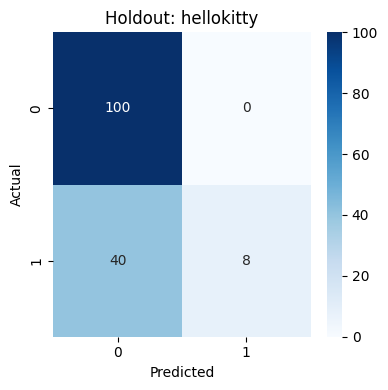


[INFO] Testing unseen family: bianlian
[INFO] Train Samples: 1759
[INFO] Test Ransomware Samples: 37
[INFO] Final Test Samples: 137
[SUCCESS] Model trained

Accuracy : 0.7445
Precision: 1.0000
Recall   : 0.0541
F1 Score : 0.1026


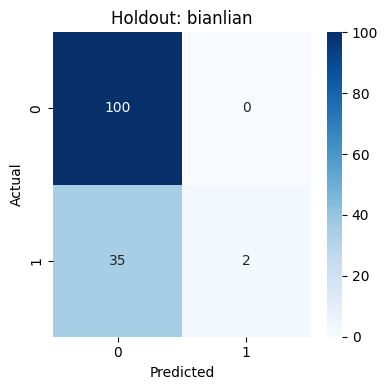


[INFO] Testing unseen family: rhysida
[INFO] Train Samples: 1759
[INFO] Test Ransomware Samples: 27
[INFO] Final Test Samples: 127
[SUCCESS] Model trained

Accuracy : 0.9449
Precision: 1.0000
Recall   : 0.7407
F1 Score : 0.8511


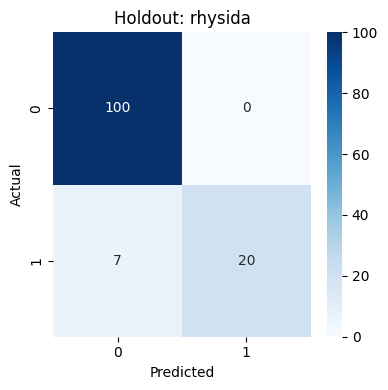


[INFO] Testing unseen family: dragonforce
[INFO] Train Samples: 1759
[INFO] Test Ransomware Samples: 20
[INFO] Final Test Samples: 120
[SUCCESS] Model trained

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


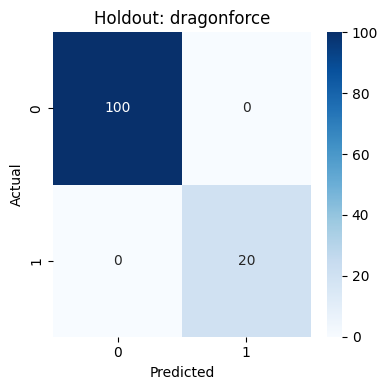


[INFO] Testing unseen family: fog
[INFO] Train Samples: 1759
[INFO] Test Ransomware Samples: 17
[INFO] Final Test Samples: 117
[SUCCESS] Model trained

Accuracy : 0.9658
Precision: 1.0000
Recall   : 0.7647
F1 Score : 0.8667


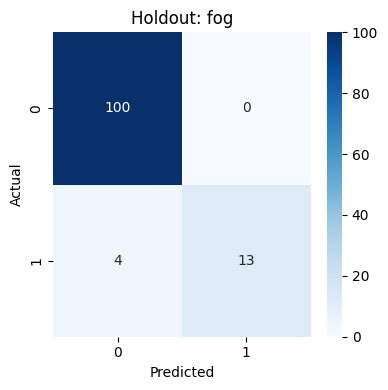


FINAL RESULTS
             samples  accuracy  precision  recall      f1
bianlian       137.0    0.7445        1.0  0.0541  0.1026
hellokitty     148.0    0.7297        1.0  0.1667  0.2857
rhysida        127.0    0.9449        1.0  0.7407  0.8511
fog            117.0    0.9658        1.0  0.7647  0.8667
dragonforce    120.0    1.0000        1.0  1.0000  1.0000


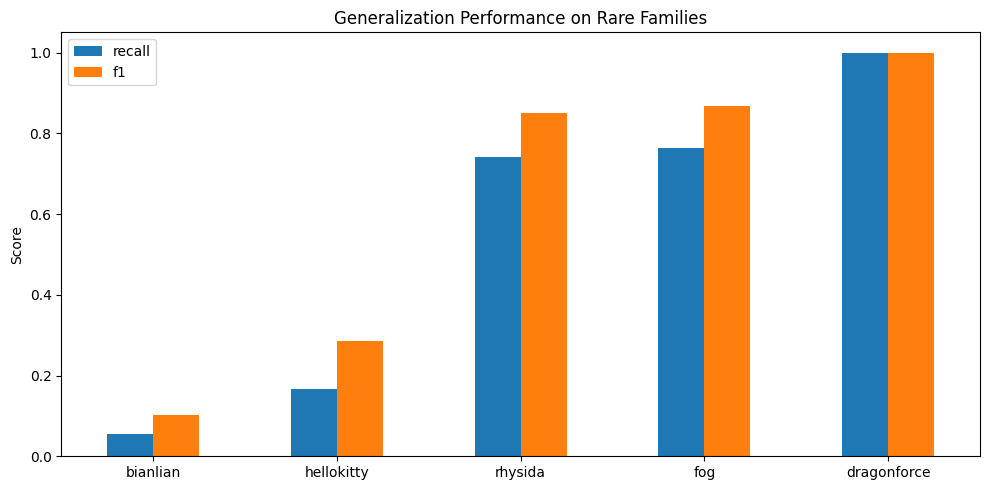

In [16]:
# ============================================
# CELL: Rare Family Generalization Experiment
# Purpose:
# Train on large ransomware families
# Test on unseen rare ransomware families
# ============================================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

# ============================================
# Load Dataset
# ============================================

df = pd.read_csv("../data/pe_features(Combined).csv")

print("[INFO] Dataset Shape:", df.shape)

# ============================================
# Prepare Features
# ============================================

DROP_COLUMNS = [

    "label",
    "family",
    "sha256",
    "file_name"

]

X = df.drop(columns=DROP_COLUMNS)

y = df["label"]

# ============================================
# Large Families Used For Training
# ============================================

TRAIN_FAMILIES = [

    "blackmatter",
    "wannacry",
    "raworld",
    "akira",
    "trigona",
    "lockbit",
    "medusa",
    "qilin",
    "cactus"

]

# ============================================
# Rare Families Used For Testing
# ============================================

HELD_OUT_FAMILIES = [

    "hellokitty",
    "bianlian",
    "rhysida",
    "dragonforce",
    "fog"

]

# ============================================
# Store Results
# ============================================

all_results = {}

# ============================================
# Main Experiment Loop
# ============================================

for UNSEEN_FAMILY in HELD_OUT_FAMILIES:

    print("\n" + "=" * 60)

    print(f"[INFO] Testing unseen family: {UNSEEN_FAMILY}")

    # ========================================
    # Create Train/Test Split
    # ========================================

    train_mask = (
    df["family"].isin(TRAIN_FAMILIES) |
    (df["family"] == "benign")         
)

    test_mask = df["family"] == UNSEEN_FAMILY

    X_train = X[train_mask]

    y_train = y[train_mask]

    X_test = X[test_mask]

    y_test = y[test_mask]

    print(f"[INFO] Train Samples: {len(X_train)}")

    print(f"[INFO] Test Ransomware Samples: {len(X_test)}")

    # ========================================
    # Add Benign Samples To Test Set
    # ========================================

    benign_mask = df["family"] == "benign"

    X_benign = X[benign_mask].sample(

        100,

        random_state=42

    )

    y_benign = y[benign_mask].sample(

        100,

        random_state=42

    )

    X_test = pd.concat([

        X_test,
        X_benign

    ])

    y_test = pd.concat([

        y_test,
        y_benign

    ])

    print(f"[INFO] Final Test Samples: {len(X_test)}")

    # ========================================
    # Train Model
    # ========================================

    model = RandomForestClassifier(

        n_estimators=200,

        random_state=42

    )

    model.fit(

        X_train,

        y_train

    )

    print("[SUCCESS] Model trained")

    # ========================================
    # Predict
    # ========================================

    pred = model.predict(X_test)

    # ========================================
    # Metrics
    # ========================================

    acc = accuracy_score(y_test, pred)

    precision = precision_score(y_test, pred)

    recall = recall_score(y_test, pred)

    f1 = f1_score(y_test, pred)

    print(f"\nAccuracy : {acc:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall   : {recall:.4f}")

    print(f"F1 Score : {f1:.4f}")

    # ========================================
    # Save Results
    # ========================================

    all_results[UNSEEN_FAMILY] = {

        "samples": len(X_test),

        "accuracy": acc,

        "precision": precision,

        "recall": recall,

        "f1": f1

    }

    # ========================================
    # Confusion Matrix
    # ========================================

    cm = confusion_matrix(

        y_test,

        pred

    )

    plt.figure(figsize=(4,4))

    sns.heatmap(

        cm,

        annot=True,

        fmt="d",

        cmap="Blues"

    )

    plt.title(

        f"Holdout: {UNSEEN_FAMILY}"

    )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.tight_layout()

    plt.show()

# ============================================
# Summary Table
# ============================================

print("\n" + "=" * 60)

print("FINAL RESULTS")

print("=" * 60)

results_df = pd.DataFrame(all_results).T

results_df = results_df.sort_values(

    "recall",

    ascending=True

)

print(results_df.round(4))

# ============================================
# Visualization
# ============================================

results_df.plot(

    kind="bar",

    y=["recall", "f1"],

    figsize=(10,5)

)

plt.title(

    "Generalization Performance on Rare Families"

)

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [17]:
# dragonforce: Accuracy=1.0, Precision=1.0, Recall=1.0
# Perfect score on unseen family = very suspicious.
# The perfect score on dragonforce is not due to similarity to blackmatter.
# Most likely reason: Dragonforce is similar to other training families (raworld, akira, trigona) in import count and crypto APIs. 
# The model learned this pattern from other families and applied it to them.

df_dragon = df[df["family"] == "dragonforce"]
df_black  = df[df["family"] == "blackmatter"]

print("DragonForce feature means:")
print(df_dragon[X.columns].mean())

print("\nBlackMatter feature means:")
print(df_black[X.columns].mean())

DragonForce feature means:
file_size        419913.300000
num_sections          5.050000
many_sections         0.000000
size_of_image    429670.400000
size_of_code     325068.800000
entry_point      213344.900000
num_imports         169.350000
num_dlls             10.100000
avg_entropy           5.701170
max_entropy           6.666638
min_entropy           4.524172
has_crypto            0.850000
has_bcrypt            0.000000
has_file_ops          0.950000
dtype: float64

BlackMatter feature means:
file_size        523031.055118
num_sections          5.559055
many_sections         0.062992
size_of_image    574478.110236
size_of_code      84556.598425
entry_point      377882.661417
num_imports          20.724409
num_dlls              2.653543
avg_entropy           5.598214
max_entropy           7.682081
min_entropy           2.602858
has_crypto            0.000000
has_bcrypt            0.000000
has_file_ops          0.015748
dtype: float64


In [18]:
# feature comparison: BianLian is structurally different from all the training families in almost every feature.
# Conclusion: BianLian evades static PE detection because it doesn't use standard Windows Crypto APIs 
# and has significantly different structural characteristics from known ransomware families.
# File size: double the average, num_dlls decreased by 72%, has_crypto = 0 (no crypto API in import table), min_entropy is very low = not packed

df_bian   = df[df["family"] == "bianlian"]
df_train  = df[df["family"].isin(TRAIN_FAMILIES)]

print("BianLian vs Training families:")
comparison = pd.DataFrame({
    "bianlian": df_bian[X.columns].mean(),
    "training_avg": df_train[X.columns].mean()
})
print(comparison.round(3))

BianLian vs Training families:
                  bianlian  training_avg
file_size      4367672.324   2091563.761
num_sections         5.919         7.171
many_sections        0.081         0.496
size_of_image  3644111.568   2165267.620
size_of_code   1336721.297    512887.836
entry_point     415081.459    443729.712
num_imports         46.108        98.479
num_dlls             1.595         5.741
avg_entropy          4.283         4.306
max_entropy          6.294         6.805
min_entropy          0.311         1.722
has_crypto           0.000         0.106
has_bcrypt           0.000         0.040
has_file_ops         0.027         0.445
